Today's date: 2026-03-16
75 [256, 256, 256] 6 [0.0, 0.0, 0.0]


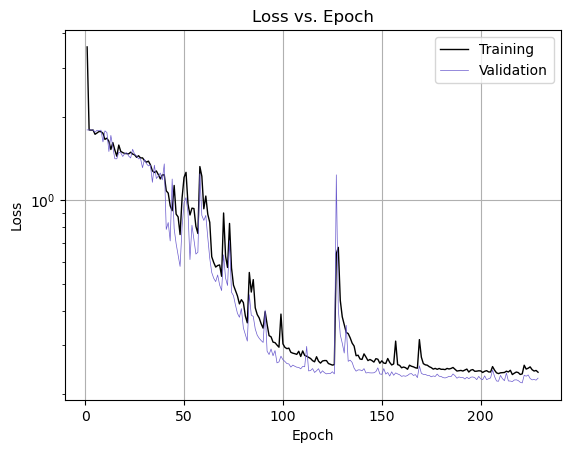

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from datetime import date, datetime

# Get the current date
today_date = date.today()
print(f"Today's date: {today_date}")

# Define the improved model
input_size = 75
hidden_layers = [256, 256,256]
output_size = 6  # Updated output_size to match the number of classes
dropout_probs= [0.0, 0.0,0.0]
lr =  1e-4
batch_size = 512


print(input_size, hidden_layers, output_size, dropout_probs)
directory = f'Figures/['
for a in range(len(hidden_layers)):
    directory += str(hidden_layers[a])+','
    if a == len(hidden_layers)-1:
        directory = directory[:-1]
        directory += ']'
if not os.path.isdir(directory):
    os.makedirs(directory)
out = directory
# Load the metrics from the CSV file
metrics_file = directory+"/training_metrics.csv"
metrics = pd.read_csv(metrics_file)
#improved_model = pd.read_csv('model_parameters.csv')


# Plot Loss vs. Epoch

#min_train_loss = metrics["Train Loss"].min()
plt.plot(metrics["Epoch"], metrics["Train Loss"], label ="Training", color="black", linewidth = 1.0)
plt.plot(metrics["Epoch"], metrics["Val Loss"], label="Validation", color="slateblue", linewidth = 0.5)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")  # Set the y-axis to logarithmic scale
plt.title("Loss vs. Epoch")
plt.legend()
plt.grid(True)  # Add grid lines

plt.savefig(directory+"/loss_vs_epoch.png", dpi=300)

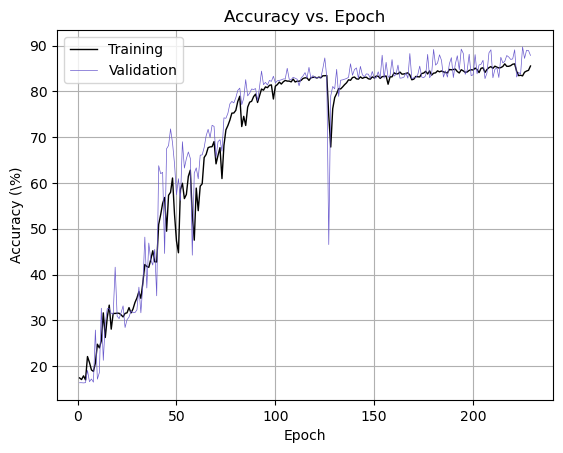

In [2]:
# Plot Accuracy vs. Epoch

max_train_accuracy = metrics["Train Accuracy"].max()
plt.plot(metrics["Epoch"], metrics["Train Accuracy"], label="Training", color="black", linewidth = 1.0)
plt.plot(metrics["Epoch"], metrics["Val Accuracy"], label="Validation", color="slateblue", linewidth = 0.5)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (\%)")
plt.title("Accuracy vs. Epoch")
plt.legend()
plt.grid(True)  # Add grid lines
plt.savefig(directory+"/accuracy_vs_Epoch.png", dpi=300)

### Training Monitoring and Confusion Check

75 [256, 256, 256] 6 [0.0, 0.0, 0.0]
File written successfully!
1
Loading checkpoint from: Figures/[256,256,256]/checkpoints\best_model.pth
12000
12000


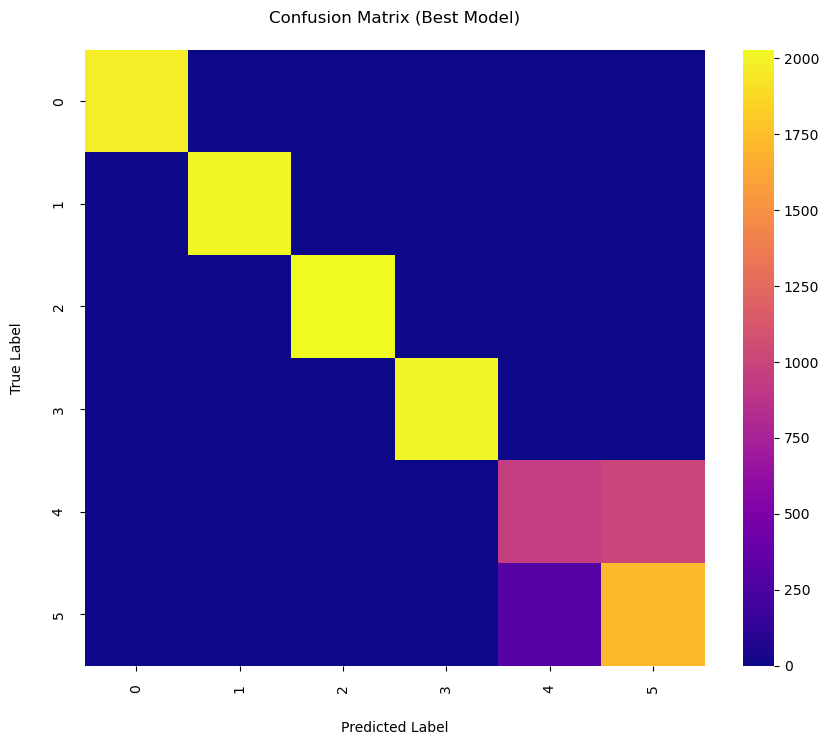

In [3]:
# ---------------------------
# Part 2: Load the Best Model State
# ---------------------------

import os
import glob
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import import_ipynb
import PTorchTraining
from PTorchTraining import CustomDataset, SimpleDNN

print(1)
# Define the checkpoints directory and the explicit best model filename
checkpoints_dir = directory+"/checkpoints"
checkpoint_path = os.path.join(checkpoints_dir, "best_model.pth")

if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Checkpoint file '{checkpoint_path}' does not exist!")

print(f"Loading checkpoint from: {checkpoint_path}")

 # Define the improved model

model = SimpleDNN()

# Load the state dictionary from the checkpoint
model.load_state_dict(torch.load(checkpoint_path))
model.eval()  # Set to evaluation mode


# Move the model to the appropriate device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ---------------------------
# Part 3: Compute and Plot the Confusion Matrix
# ---------------------------

all_preds = []
all_labels = []

with open(directory+"/val_loader.pkl", "rb") as f:
    val_loader = pickle.load(f)

with torch.no_grad():
    for data, labels in val_loader:
        data, labels = data.to(device), labels.to(device)
        outputs = model(data)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
print(len(all_preds))
print(len(all_labels))
# Compute the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Define custom class labels
class_labels = [f"{str(n)}" for n in range(output_size)]

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(10, 8)) # Increasing figure size often helps with crowding
ax = sns.heatmap(cm, annot=False, fmt='d', cmap='plasma',
                xticklabels=class_labels, yticklabels=class_labels)

plt.title("Confusion Matrix (Best Model)", pad=20) # 'pad' adds space below the title

# 1. Increase gap for Axis Titles using 'labelpad'
plt.xlabel("Predicted Label", labelpad=20) 
plt.ylabel("True Label", labelpad=20)

# 2. Increase gap for Tick Labels (class names) using tick_params
ax.tick_params(axis='x', which='major', pad=10)
ax.tick_params(axis='y', which='major', pad=10)

# Rotate labels
plt.xticks(rotation=90)
# plt.yticks(rotation=45)

plt.savefig(directory+"/4x4_Confusion_Matrix.png", dpi=500, bbox_inches='tight')
plt.show()


### Inference Stage

Interpret experimental data.

Loading checkpoint from: Figures/[256,256,256]/checkpoints\best_model.pth


C:\Users\NHP-Jhom\AppData\Local\Temp\ipykernel_23408\1815760658.py:126: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  sample = np.array(sample)


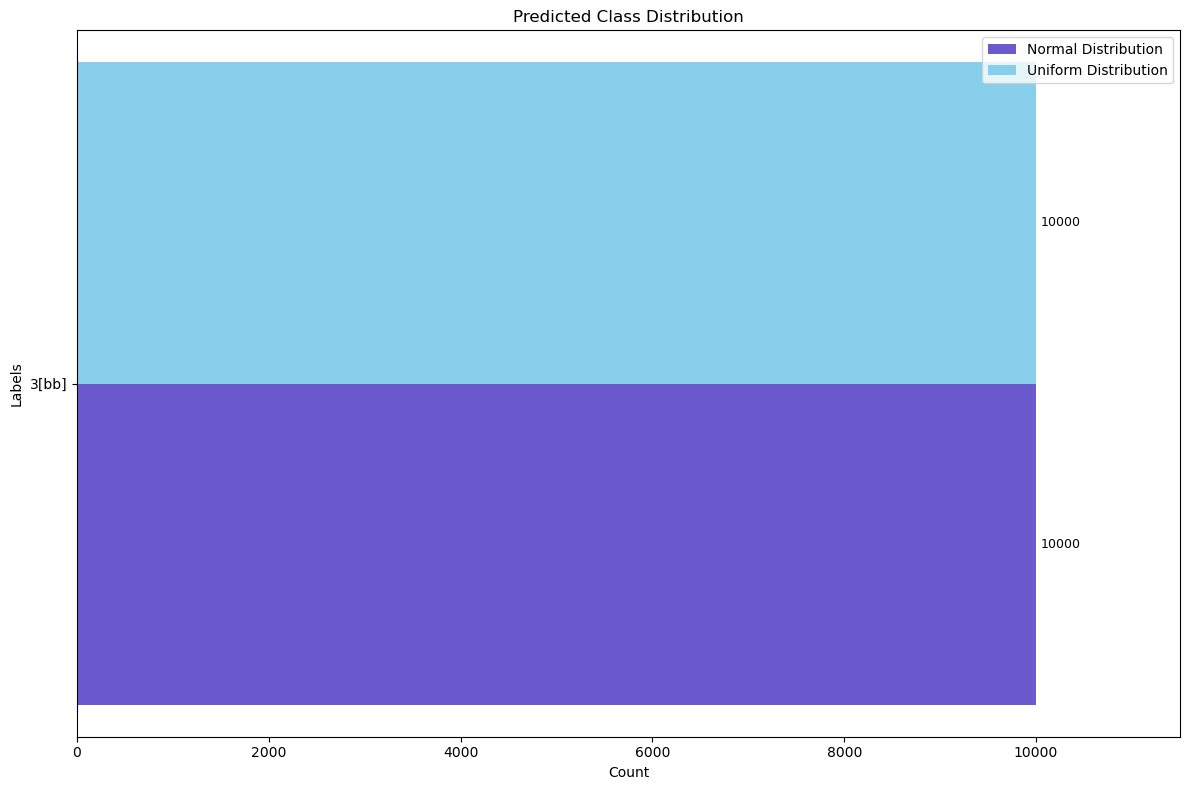

In [6]:
## import os
import random
import numpy as np
import torch
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Import your model class
import import_ipynb
import PTorchTraining
from PTorchTraining import CustomDataset, SimpleDNN

# -------------------------------------------------------------------
# (A) Real-World Data and Generation Functions
# -------------------------------------------------------------------
LHCb_data = np.loadtxt('Zc3900_D0Dbarstar.csv', skiprows=1, delimiter=',')
invmass = LHCb_data[:, 0]
invmass_low = LHCb_data[:, 4]
invmass_high = LHCb_data[:, 5]
weighted_candidates = LHCb_data[:,1]
upper_err = np.abs(LHCb_data[:, 2])  # Ensure non-negative
lower_err = np.abs(LHCb_data[:, 2])  # Ensure non-negative


# In this example, we'll use each event's lower and upper invariant mass as thresholds.
# (In your original code, energy_low and energy_high were set to these arrays.)
energy_low = invmass_low
energy_high = invmass_high


def gen_Eaxis():
    """Generate random x values for each event based on invmass lower and upper bounds."""
    x_data = []
    for i in range(len(invmass)):
        x_val = random.uniform(invmass_low[i], invmass_high[i])
        x_data.append(x_val)
    return np.array(x_data)

def gen_Amp_unif():
    """Generate amplitudes using a uniform distribution."""
    y_data = []
    for i in range(len(weighted_candidates)):
        y_val = np.random.uniform(weighted_candidates[i]-upper_err[i],
                                  weighted_candidates[i]+upper_err[i])
        y_data.append(y_val)
    return np.array(y_data)

def gen_Amp_norm():
    """Generate amplitudes using a normal distribution."""
    y_data = []
    for i in range(len(weighted_candidates)):
        y_val = np.random.normal(weighted_candidates[i], upper_err[i]/3)
        y_data.append(y_val)
    return np.array(y_data)
def gen_Exp(amp_func):
    """
    Generate a single experimental sample
    Matches CustomDataset.__getitem__()

    Output:
        input_tensor: torch.FloatTensor of shape (1, 2, N)
    """

    # Generate raw data
    energy = gen_Eaxis()        # (N,)
    intensity = amp_func()      # (N,)

    # Apply identical masking logic
    mask = (energy < energy_high) & (energy >= energy_low)
    energy = energy[mask]
    intensity = intensity[mask]

    # Enforce float32 (matches dataset tensors)
    energy = np.asarray(energy, dtype=np.float32)
    intensity = np.asarray(intensity, dtype=np.float32)



    # Convert to torch
    energy_tensor = torch.tensor(energy)
    intensity_tensor = torch.tensor(intensity)

    # EXACT same stacking as CustomDataset.__getitem__()
    input_tensor = torch.stack((energy_tensor, intensity_tensor), dim=0)

    return input_tensor
# -------------------------------------------------------------------
# (B) Generate Experimental Data for Both Distributions
# -------------------------------------------------------------------
num_samples = 10000

# Generate one set with normal amplitude generation and the other with uniform.
Exp_data_norm = [gen_Exp(gen_Amp_norm) for _ in range(num_samples)]
Exp_data_unif = [gen_Exp(gen_Amp_unif) for _ in range(num_samples)]



# -------------------------------------------------------------------
# (C) Load the Trained DNN Model
# -------------------------------------------------------------------
# Define the improved model

model = SimpleDNN()


checkpoint_path = os.path.join(checkpoints_dir, "best_model.pth")
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Checkpoint file '{checkpoint_path}' does not exist!")
print(f"Loading checkpoint from: {checkpoint_path}")
# Load the state dictionary from the checkpoint, mapping to CPU
model.load_state_dict(torch.load(checkpoint_path, map_location='cpu'))
model.eval()  # Set model to evaluation mode

# Move model to available device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# -------------------------------------------------------------------
# (D) Define a Helper Function to Run Inference on a List of Samples
# -------------------------------------------------------------------
def get_predictions(exp_data, input_size, model, device):
    predicted = []
    with torch.no_grad(): # Add no_grad for inference to save memory and speed up
        for sample in exp_data:
            sample = np.array(sample)
            # Adjust sample length to match model's expected input size.
            #if sample.shape[0] < input_size:
             #   sample = np.pad(sample, (0, input_size - sample.shape[0]), mode='constant')
            #elif sample.shape[0] > input_size:
             #   sample = sample[:input_size]
            # Convert sample into a tensor and add batch dimension.
            # Ensure the tensor is on the correct device before passing it to the model
            sample_tensor = torch.tensor(sample, dtype=torch.float32).unsqueeze(0).to(device)
            # Get predicted class.
            output = model(sample_tensor)
            _, pred = torch.max(output, 1)
            predicted.append(pred.item())
    return predicted

# Get predictions for both sets.
predicted_norm = get_predictions(Exp_data_norm, input_size, model, device)
predicted_unif = get_predictions(Exp_data_unif, input_size, model, device)

# Count the occurrences of each predicted class.
counts_norm = Counter(predicted_norm)
counts_unif = Counter(predicted_unif)

# -------------------------------------------------------------------
# (E) Plot the Predicted Class Distributions Side by Side
# -------------------------------------------------------------------

# Define custom class labels with LaTeX formatting.
# Define custom class labels
# Define custom class labels
custom_labels = [f"{str(n)}" for n in range(output_size)]
# Prepare data for plotting.
valid_indices = [
    i for i in range(output_size) 
    if counts_norm.get(i, 0) != 0 and counts_unif.get(i, 0) != 0
]


labels = [
    "1[bt], 1[tb], 2[bb]",
    "no pole",
    "2[tb]",
    "3[bb]",
    "1[bt]",
    "1[bt], 3[tb]"
]


# 2. Build your lists using ONLY those valid indices
classes = [custom_labels[i] for i in valid_indices]
values_norm = [counts_norm.get(i) for i in valid_indices]
values_unif = [counts_unif.get(i) for i in valid_indices]

custom_labels_remaining = [labels[i] for i in valid_indices]

# -------------------------------------------------------------------
# (E) Plot the Predicted Class Distributions Side by Side (Updated)
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 8)) # Increased size slightly for readability

bar_height = 0.35
br1 = np.arange(len(custom_labels_remaining))
br2 = [y + bar_height for y in br1]

# Plot for the normal amplitude distribution
rects1 = ax.barh(br1, values_norm, color="slateblue", height=bar_height, label="Normal Distribution")

# Plot for the uniform amplitude distribution
rects2 = ax.barh(br2, values_unif, color="skyblue", height=bar_height, label="Uniform Distribution")

# --- NEW: Add the actual counts on the bars ---
# padding=3 moves the text slightly to the right of the bar end
ax.bar_label(rects1, padding=3, fontsize=9)
ax.bar_label(rects2, padding=3, fontsize=9)

# Swapping X and Y labels
ax.set_ylabel('Labels')
ax.set_xlabel('Count')
ax.set_title("Predicted Class Distribution")

# Extend the x-axis limits slightly to make room for the labels
ax.set_xlim(0, max(max(values_norm), max(values_unif)) * 1.15)

# Center the y-ticks between the grouped bars
ax.set_yticks(br1 + bar_height / 2)
ax.set_yticklabels(custom_labels_remaining)

ax.legend()
plt.tight_layout()

# Ensure directory variable exists or use current path
save_path = "Classification_Horizontal.png"
if 'directory' in locals():
    save_path = os.path.join(directory, save_path)
    
plt.savefig(save_path, dpi=300)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Calculate precision, recall, f1-score, support, accuracy, macro avg and weighted avg
report = classification_report(all_labels, all_preds, target_names=labels)

# Print the classification report
print(report)

file_path = directory+'/classification_report.txt'
with open(file_path, 'w') as f:
    f.write(report)

print(f"Classification report saved to {file_path}")

In [ ]:
from datetime import date, datetime

# Get the current date
today_date = date.today()
print(f"Today's date: {today_date}")
